In [1]:
import pandas as pd
import re
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from afinn import Afinn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
yelp_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/train.csv")
yelp_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/dev.csv")
yelp_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/test.csv")

dynabench_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/train.csv")
dynabench_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/dev.csv")
dynabench_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/test.csv")

yelp_dynabench_2500_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/train.csv")
yelp_dynabench_2500_dev_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/dev.csv")
yelp_dynabench_2500_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/test.csv")

In [3]:
yelp_df = pd.concat([yelp_train_df, yelp_dev_df, yelp_test_df])
dynabench_df = pd.concat([dynabench_train_df, dynabench_dev_df, dynabench_test_df])
yelp_dynabench_2500_df = pd.concat([yelp_dynabench_2500_train_df, yelp_dynabench_2500_dev_df, yelp_dynabench_2500_test_df])

In [4]:
dataFrames = [yelp_df, dynabench_df, yelp_dynabench_2500_df]

# Mapping function
label_mapping = {'positive': 1, 'neutral': 0, 'negative': -1}

# Iterate over each DataFrame name
for df in dataFrames:
    
    # Apply the mapping to the 'label' column
    df['label'] = df['label'].map(label_mapping)

# Example to check the changes
print(yelp_df.head())

                                                text  label
0  I haven't been on an AA flight that hasn't bee...     -1
1  Went differently because of his reviews and pr...      0
2         So if you see this dog, AVOID AVOID AVOID!     -1
3                 De-li-cious tacos for $9 straight.      1
4          He them saw me, and asked what was wrong.      0


In [5]:

def preprocess_with_lemmatization(data):
    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Define stop words
    stop_words = set(stopwords.words('english'))
    
    # Preprocessing function
    def preprocess_text(text):
        # Remove non-alphabetic characters
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        # Convert to lowercase
        text = text.lower()
        # Tokenize
        words = word_tokenize(text)
        # Remove stop words and apply lemmatization
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return ' '.join(words)
    
    # Apply preprocessing to each row in the dataframe
    data['text'] = data['text'].apply(preprocess_text)
    
    return data


In [6]:
for df in dataFrames:
    df = preprocess_with_lemmatization(df)

# Example to check the changes
print(yelp_df.head())

                                               text  label
0           havent aa flight hasnt delayed canceled     -1
1  went differently review proximity ann centennial      0
2                         see dog avoid avoid avoid     -1
3                           delicious taco straight      1
4                                   saw asked wrong      0


In [7]:
# Initialize the AFINN sentiment analyzer
afinn = Afinn()

# Function to get the sentiment label
def get_sentiment_label(text):
    score = afinn.score(text)
    if score > 0:
        return 1  # Positive
    elif score < 0:
        return -1  # Negative
    else:
        return 0  # Neutral

# Assuming dataFrames contains your dataframes
# Apply the function to each dataframe
for df in dataFrames:
    df['predicted_label'] = df['text'].apply(get_sentiment_label)

# Example to check the changes
print(yelp_df.head())

                                               text  label  predicted_label
0           havent aa flight hasnt delayed canceled     -1               -1
1  went differently review proximity ann centennial      0                0
2                         see dog avoid avoid avoid     -1               -1
3                           delicious taco straight      1                1
4                                   saw asked wrong      0               -1


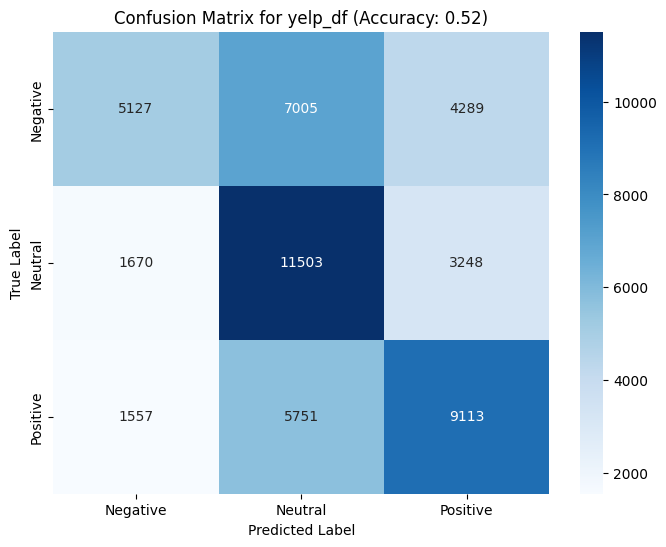

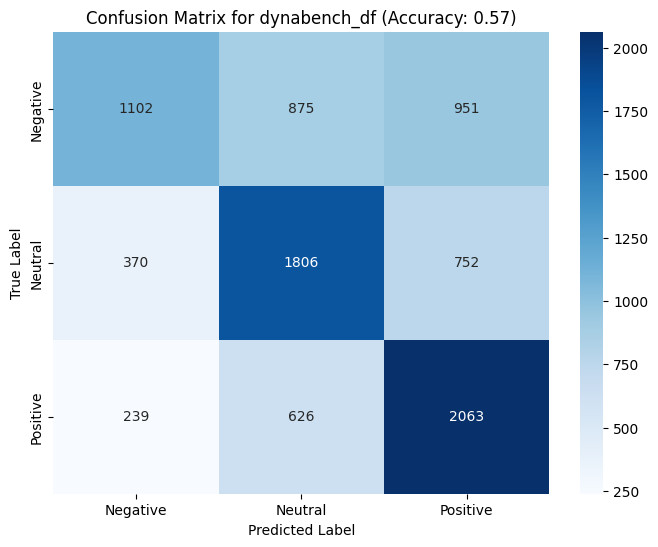

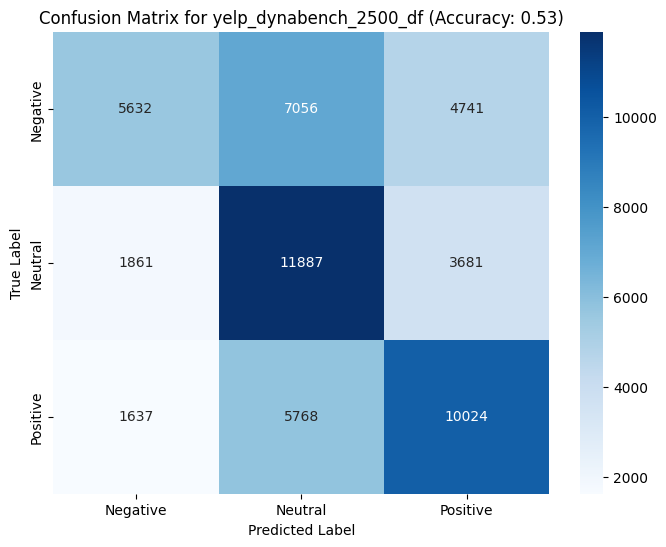

In [8]:
# Function to calculate accuracy and plot confusion matrix
def evaluate_sentiment(df, df_name):
    accuracy = accuracy_score(df['label'], df['predicted_label'])
    conf_matrix = confusion_matrix(df['label'], df['predicted_label'])
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {df_name} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Assuming dataFrames contains your dataframes
# Evaluate each dataframe
for df_name, df in zip(['yelp_df', 'dynabench_df', 'yelp_dynabench_2500_df'], dataFrames):
    evaluate_sentiment(df, df_name)